# Análisis exploratorio: detección de fraude

El objetivo del proyecto es entrenar un modelo que maximice la **ganancia del negocio**. 

Una transacción legítima que aprobamos deja un 25% de su monto como ganancia, mientras que un fraude que aprobamos nos hace perder el 100% del monto. 

Este notebook es exploración. La idea es entender el dataset, su calidad y cómo se relacionan las variables con el fraude, mirando siempre el peso económico del problema.

Trabajo únicamente sobre el conjunto de dev y dejo afuera la última semana del período, reservada como test. Aunque esto es solo exploración, mirar la distribución de test podría sesgar las decisiones de modelado que vienen después, así que permanece intacto hasta la evaluación final (Ver más del split en Notebook 02).

Todavía no transformo nada: las decisiones de limpieza, encoding, manejo del desbalance, selección de features, modelo y umbral las dejo para los notebooks que siguen. 

## 1. Setup

In [1]:
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Presentación
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (7, 3.5)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
warnings.filterwarnings("ignore", category=FutureWarning)

# Código común y ruta del dataset.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.business import ganancia_aprobar_todo as calcular_ganancia_aprobar_todo
from src.business import ganancia_por_operacion, ganancia_total
from src.data import TARGET, DEFAULT_DATA_PATH, cargar_datos

DATA_PATH = DEFAULT_DATA_PATH

In [2]:
from src.validation import TEST_START

# El EDA se hace solo sobre el conjunto de dev (desarrollo). La semana de test
# queda intacta: mirar su distribución podría sesgar las decisiones de modelado posteriores.

df_completo = cargar_datos(DATA_PATH)
fecha_completa = pd.to_datetime(df_completo["fecha"])
df = df_completo.loc[fecha_completa < TEST_START].reset_index(drop=True)

print(f"Dataset completo: {len(df_completo):,} filas  |  Columnas: {df.shape[1]}")
print(f"dev (lo que usa este EDA): {len(df):,} filas")
print(f"Test excluido (desde {TEST_START.date()}): {len(df_completo) - len(df):,} filas")
df.head()  # Muestra

Dataset completo: 150,000 filas  |  Columnas: 19
dev (lo que usa este EDA): 121,014 filas
Test excluido (desde 2020-04-15): 28,986 filas


,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,"50,084.1200",50.0000,0.0000,20.0000,AR,1,cat_d26ab52,0.3655,"2,479.0000",952.0000,1,NaN,Y,2020-03-20 09:28:19,57.6300,100,0
1,4,0.6694,"66,005.4900",0.0000,0.0000,2.0000,AR,1,cat_ea962fb,0.6127,"2,603.0000",105.0000,1,Y,Y,2020-03-09 13:58:28,40.1900,25,0
2,4,0.4718,"7,059.0500",4.0000,0.4635,92.0000,BR,25,cat_4c2544e,0.6518,"2,153.0000",249.0000,1,Y,Y,2020-04-08 12:25:55,5.7700,23,0
3,4,0.7260,"10,043.1000",24.0000,0.0468,43.0000,BR,43,cat_1b59ee3,0.6927,"4,845.0000",141.0000,1,N,Y,2020-03-14 11:46:13,40.8900,23,0
4,4,0.7758,"16,584.4200",2.0000,0.1546,54.0000,BR,0,cat_9bacaa5,0.2014,"2,856.0000",18.0000,1,Y,N,2020-03-23 14:17:13,18.9800,71,0


## 2. Vistazo general

Las features vienen anonimizadas, de la a a la p (sin la i), y a eso se suman fecha, monto, score y el target fraude. Como no tenemos la semántica de cada columna, hay que ver de qué tipo es cada una mirando su contenido: si es categórica, binaria, discreta o continua.

In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "valores_unicos": df.nunique(),
})

info

,dtype,no_nulos,valores_unicos
a,int64,121014,4
b,float64,108300,7357
c,float64,108300,107013
d,float64,120677,51
e,float64,121014,36218
f,float64,121003,1238
g,object,120873,45
h,int64,121014,59
j,object,121014,7898
k,float64,121014,121014


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
a,"121,014.0000",3.6977,0.7604,1.0000,4.0000,4.0000,4.0000,4.0000
b,"108,300.0000",0.7283,0.1326,0.0000,0.6803,0.7549,0.8056,1.0000
c,"108,300.0000","258,798.9984","836,643.8023",0.1600,"9,745.8950","43,701.3200","144,810.5750","13,878,743.7100"
d,"120,677.0000",21.6025,20.0144,0.0000,2.0000,14.0000,50.0000,50.0000
e,"121,014.0000",0.2205,2.6927,0.0000,0.0000,0.0994,0.2797,833.3333
f,"121,003.0000",51.2529,634.8797,-4.0000,1.0000,8.0000,33.0000,"145,274.0000"
h,"121,014.0000",14.1883,14.1247,0.0000,3.0000,9.0000,21.0000,58.0000
k,"121,014.0000",0.4976,0.2883,0.0000,0.2467,0.4965,0.7467,1.0000
l,"121,003.0000","2,305.4720","1,711.5564",0.0000,910.0000,"1,938.0000","3,442.0000","7,544.0000"
m,"120,677.0000",299.7936,320.6164,0.0000,42.0000,194.0000,459.0000,"2,215.0000"


Mirando cardinalidad, rango y tipo, agrupo las columnas provisionalmente para ordenar la exploración. 

- Target: fraude (0 o 1)
- Binarias o flags: n (0/1), p (Y/N) y o (Y/N, + muchos faltantes)
- Categóricas de baja cardinalidad: a (4 niveles) y g (parece país: BR, AR, UY)
- Categórica de alta cardinalidad: j (tipo cat_xxx, miles de niveles)
- Numéricas continuas: b, c, e, k y monto
- Numéricas discretas: d, f, h, l y m
- score (0 a 100), posiblemente el score de otro sistema de fraude
- fecha

In [5]:
COL_BINARIAS  = ["n", "p", "o"]
COL_CAT_BAJA  = ["a", "g"]
COL_CAT_ALTA  = ["j"]
COL_CONTINUAS = ["b", "c", "e", "k", "monto"]
COL_DISCRETAS = ["d", "f", "h", "l", "m"]
COL_SCORE     = ["score"]
COL_TIEMPO    = ["fecha"]

# Numéricas para correlación / distribuciones (excluye categóricas de texto).
COL_NUMERICAS = COL_CONTINUAS + COL_DISCRETAS + COL_SCORE + ["n"]

## 3. Calidad de datos y faltantes

In [6]:
faltantes = pd.DataFrame({
    "n_faltante": df.isna().sum(),
    "pct_faltante": df.isna().mean(),
}).query("n_faltante > 0").sort_values("pct_faltante", ascending=False)
faltantes

,n_faltante,pct_faltante
o,87654,0.7243
b,12714,0.1051
c,12714,0.1051
d,337,0.0028
m,337,0.0028
g,141,0.0012
f,11,0.0001
l,11,0.0001


In [7]:
# b y c faltan en las mismas filas?
solo_b = (df["b"].isna() & df["c"].notna()).sum()
solo_c = (df["c"].isna() & df["b"].notna()).sum()
ambas  = (df["b"].isna() & df["c"].isna()).sum()
print(f"Faltan ambas (b y c): {ambas:,}  |  solo b: {solo_b:,}  |  solo c: {solo_c:,}")

Faltan ambas (b y c): 12,714  |  solo b: 0  |  solo c: 0


In [8]:
# Buscamos otros pares de columnas que compartan el patrón de ausencia.
cols_con_faltantes = faltantes.index.tolist()
pares_mismo_patron = []
for i, c1 in enumerate(cols_con_faltantes):
    for c2 in cols_con_faltantes[i + 1:]:
        if df[c1].isna().equals(df[c2].isna()):
            pares_mismo_patron.append((c1, c2, df[c1].isna().sum()))

pd.DataFrame(pares_mismo_patron, columns=["col_1", "col_2", "filas_compartidas"])

,col_1,col_2,filas_compartidas
0,b,c,12714
1,d,m,337
2,f,l,11


In [9]:
# La AUSENCIA de un valor aporta señal? Comparamos la tasa de fraude
# entre filas donde la columna falta vs donde está presente.
tasa_base = df[TARGET].mean()
filas = []
for c in faltantes.index:
    falta = df[c].isna()
    filas.append({
        "col": c,
        "pct_faltante": falta.mean(),
        "fraude_cuando_falta": df.loc[falta, TARGET].mean(),
        "fraude_cuando_presente": df.loc[~falta, TARGET].mean(),
    })
miss_vs_target = pd.DataFrame(filas).set_index("col")
print(f"Tasa de fraude global: {tasa_base:.4f}")
miss_vs_target

Tasa de fraude global: 0.0517


,pct_faltante,fraude_cuando_falta,fraude_cuando_presente
col,,,
o,0.7243,0.0210,0.1325
b,0.1051,0.0620,0.0505
c,0.1051,0.0620,0.0505
d,0.0028,0.0831,0.0517
m,0.0028,0.0831,0.0517
g,0.0012,0.0638,0.0517
f,0.0001,0.0000,0.0518
l,0.0001,0.0000,0.0518


fraude_cuando_falta y fraude_cuando_presente dividen las filas en dos grupos: las filas donde ese dato falta, y las filas donde está. Cada una muestra la tasa de fraude calculada solo dentro de su grupo, para comparar contra la tasa base (5,2%).

Con o se ve que falta en el 72% de los casos, y cuando falta la tasa de fraude es 2%, la mitad de la base, cuando está presente, es de alrededor del 13%, más del doble de la base. Esa diferencia hace pensar que la ausencia de o es **informativa**, y no un dato al azar.

b y c faltan en las mismas filas (10,5% de los casos), lo que sugiere que probablemente podrían venir del mismo proceso. También comparten el patrón de ausencia d con m (337 filas) y f con l (11 filas). En b y c la diferencia entre faltante y presente es bastante más chica, para el resto hay tan pocas filas faltantes que sus tasas son inestables y no conviene interpretarlas mucho.

La implicancia para modelado: si la ausencia trae señal, como en o, conviene tratarla como una categoría más. Esa decisión queda para la etapa de modelado.

Antes de seguir con la búsqueda de filas repetidas, retomo algo que apareció en la tabla general: k tiene todos sus valores distintos, uno por cada fila. Con esto podría ser un identificador (a simple vista no lo parece), una variable continua o ruido, pero su unicidad hace que dos filas nunca puedan ser exactamente iguales si la incluimos. Por eso hago el chequeo completo y lo repito sin k, para que esa columna no esconda posibles duplicados en el resto

In [10]:
print(f"Filas duplicadas (todas las columnas iguales): {df.duplicated().sum()}")
print(f"Filas duplicadas sin contar k: {df.drop(columns='k').duplicated().sum()}")
print(f"Filas duplicadas en fecha + monto + score: {df.duplicated(subset=['fecha', 'monto', 'score']).sum()}")

Filas duplicadas (todas las columnas iguales): 0
Filas duplicadas sin contar k: 0
Filas duplicadas en fecha + monto + score: 0


No hay filas exactamente duplicadas ni dejando afuera a k. Tampoco aparecen coincidencias exactas en fecha, monto y score. Estos chequeos descartan repeticiones idénticas, pero no prueban que no existan transacciones duplicadas con alguna marca de tiempo o atributo distinto.

## 4. Variable objetivo

fraude
legítima    114752
fraude        6262
Name: count, dtype: int64

Tasa de fraude: 5.1746%


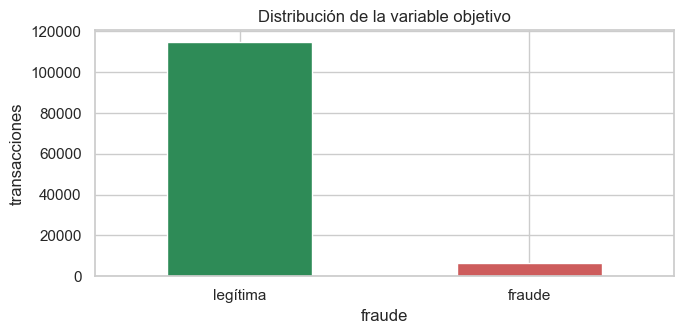

In [11]:
conteo = df[TARGET].value_counts().rename({0: "legítima", 1: "fraude"})
print(conteo)
print(f"\nTasa de fraude: {df[TARGET].mean():.4%}")

ax = conteo.plot.bar(rot=0, color=["seagreen", "indianred"])
ax.set_ylabel("transacciones")
ax.set_title("Distribución de la variable objetivo")
plt.tight_layout()
plt.show()

El dataset tiene alrededor de un 5% de fraude (5,2%), 6.262 casos sobre 121.014, un desbalance moderado. De acá salen dos cosas:

- La **accuracy miente**: un modelo que apruebe todo acierta el 95% sin haber aprendido nada útil. Por eso la evaluación va a ser en términos de ganancia económica y otras métricas.
- El umbral de decisión no debería ser 0,5 por defecto. Tiene que salir de comparar cuánto esperamos ganar si la operación es legítima contra cuánto esperamos perder si es fraude. Esa cuenta se hace más adelante, al pasar al lente económico.

## 5. Distribuciones univariadas

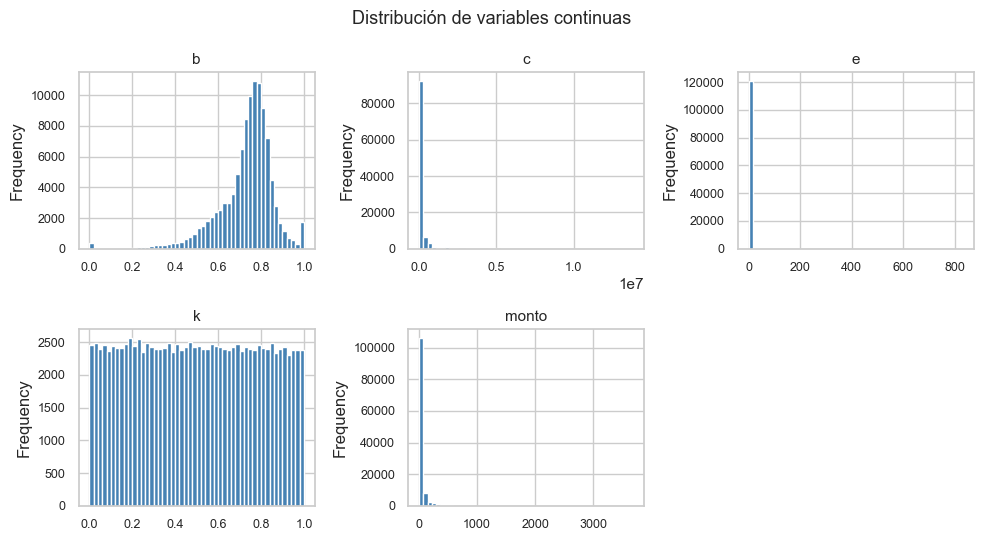

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
for ax, c in zip(axes.ravel(), COL_CONTINUAS):
    df[c].plot.hist(bins=50, ax=ax, color="steelblue")
    ax.set_title(c, fontsize=11)
    ax.tick_params(labelsize=9)
for ax in axes.ravel()[len(COL_CONTINUAS):]:
    ax.axis("off")
fig.suptitle("Distribución de variables continuas", fontsize=13)
plt.tight_layout()
plt.show()

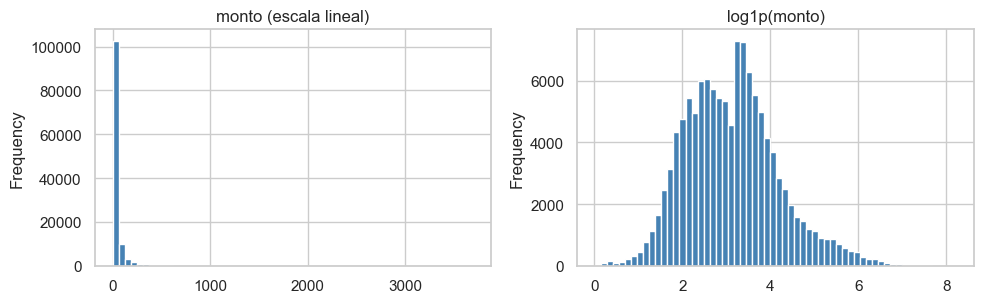

count   121,014.0000
mean         43.7601
std          91.6379
min           0.0200
25%           9.4700
50%          20.9300
75%          41.0375
max       3,696.3500
Name: monto, dtype: float64

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
df["monto"].plot.hist(bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("monto (escala lineal)")
np.log1p(df["monto"]).plot.hist(bins=60, ax=axes[1], color="steelblue")
axes[1].set_title("log1p(monto)")
plt.tight_layout()
plt.show()

df["monto"].describe()

En los histogramas anteriores, c, e y f también quedaron comprimidas cerca de cero. Hago la misma prueba que con monto para ver mejor el cuerpo de sus distribuciones. En c y e uso log1p porque no tienen valores negativos. f llega hasta -4, así que uso una versión con signo: conserva de qué lado de cero está cada valor y aplica log1p sobre su valor absoluto.

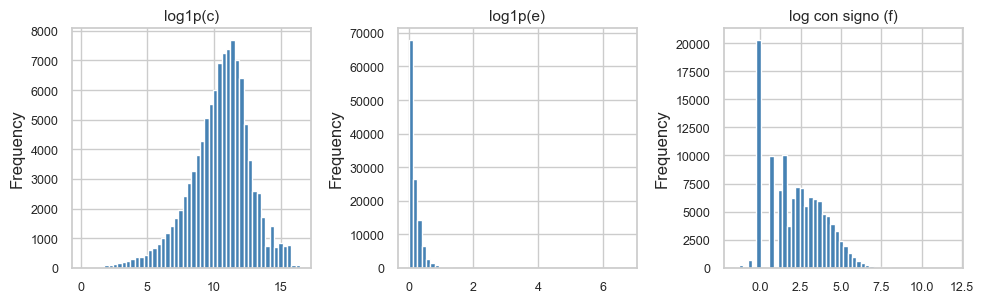

In [14]:
transformadas = pd.DataFrame({
    "log1p(c)": np.log1p(df["c"]),
    "log1p(e)": np.log1p(df["e"]),
    "log con signo (f)": np.sign(df["f"]) * np.log1p(df["f"].abs()),
})

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, col in zip(axes, transformadas.columns):
    transformadas[col].plot.hist(bins=50, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=11)
    ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

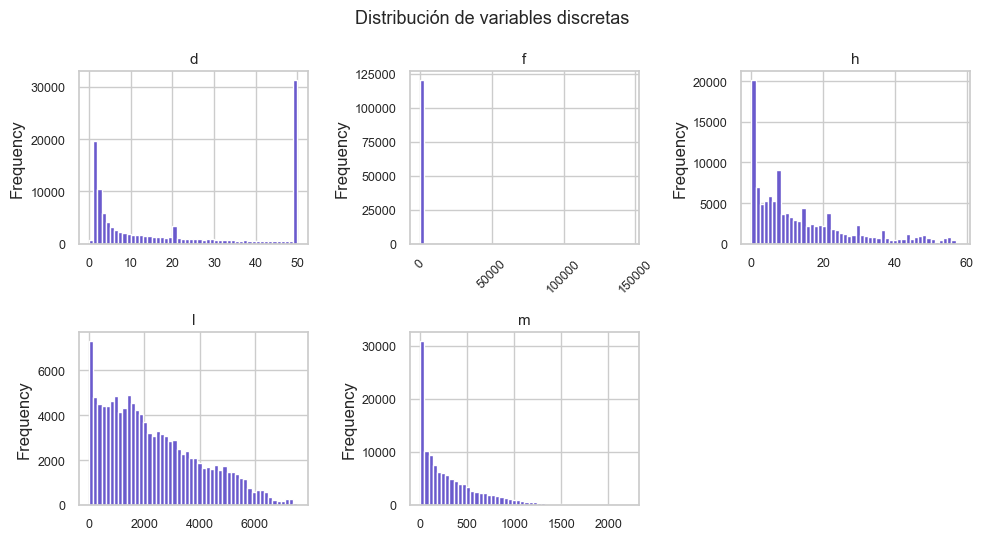

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
for ax, c in zip(axes.ravel(), COL_DISCRETAS):
    df[c].plot.hist(bins=50, ax=ax, color="slateblue")
    ax.set_title(c, fontsize=11)
    ax.tick_params(labelsize=9)
    if c == "f":  # f tienelabels  números grandes: los inclinamos para que no se solapen
        ax.tick_params(axis="x", labelrotation=45)
for ax in axes.ravel()[len(COL_DISCRETAS):]:
    ax.axis("off")
fig.suptitle("Distribución de variables discretas", fontsize=13)
plt.tight_layout()
plt.show()

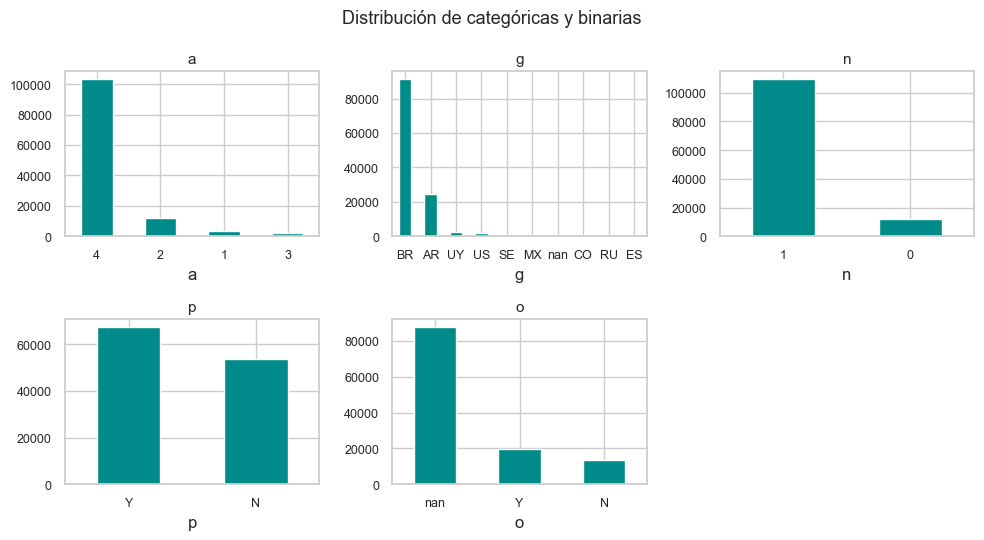

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
cols = COL_CAT_BAJA + COL_BINARIAS
for ax, c in zip(axes.ravel(), cols):
    df[c].value_counts(dropna=False).head(10).plot.bar(rot=0, ax=ax, color="darkcyan")
    ax.set_title(c, fontsize=11)
    ax.tick_params(labelsize=9)
for ax in axes.ravel()[len(cols):]:
    ax.axis("off")
fig.suptitle("Distribución de categóricas y binarias", fontsize=13)
plt.tight_layout()
plt.show()

En la tabla general vimos que j (string) tiene 7.898 categorías. Su cardinalidad es alta, pero no dice cómo se reparten las 121.014 filas: podría haber muchas categorías con bastante información o miles que aparecen solo una o dos veces.

La diferencia importa porque una categoría con pocas filas no permite estimar una tasa de fraude confiable. Antes de pensar cómo tratar j más adelante, miro entonces cuántas veces aparece cada categoría.

In [17]:
# En j no alcanza con contar niveles: también importa cuántas veces aparece cada uno.
frecuencia_j = df["j"].value_counts()
resumen_j = pd.Series({
    "categorias": frecuencia_j.size,
    "apariciones_mediana": frecuencia_j.median(),
    "categorias_con_1_fila": frecuencia_j.eq(1).sum(),
    "categorias_con_menos_de_5_filas": frecuencia_j.lt(5).sum(),
    "max_apariciones": frecuencia_j.max(),
})
resumen_j

categorias                        7,898.0000
apariciones_mediana                   3.0000
categorias_con_1_fila             2,310.0000
categorias_con_menos_de_5_filas   4,580.0000
max_apariciones                   1,910.0000
dtype: float64

En definitiva:
- monto está muy sesgado hacia la derecha, con una cola larga de montos altos, en escala logarítmica se ve casi simétrico. Un modelo sensible a la escala se va a beneficiar de una transformación log, aunque eso es decisión de modelado.
- e tiene una masa grande en cero y el resto de los valores continuos, así que parece una mezcla entre un cero y un valor.
- **k es única por fila**. Eso podría teóricamente corresponder a un id (no parece a simple vista), a ruido o a una variable continua legítima: la unicidad sola no alcanza para decidirlo. Queda investigar su utilidad.
- j tiene miles de niveles y muchas categorías poco frecuentes. Esto hace que un one-hot no sea práctico y que cualquier análisis basado en la tasa de fraude por categoría sea muy inestable en los niveles raros

### 5.1. Distribuciones en fraude y operaciones legítimas

Para ver si sus distribuciones cambian con el fraude, comparo seis variables representativas. En monto, c y e uso log1p para que unos pocos valores muy altos no compriman el resto del gráfico, en f uso la transformación con signo porque contiene valores negativos. Esto sigue siendo una comparación descriptiva: una separación visible no asegura que la variable aporte lo mismo cuando se combine con las demás.

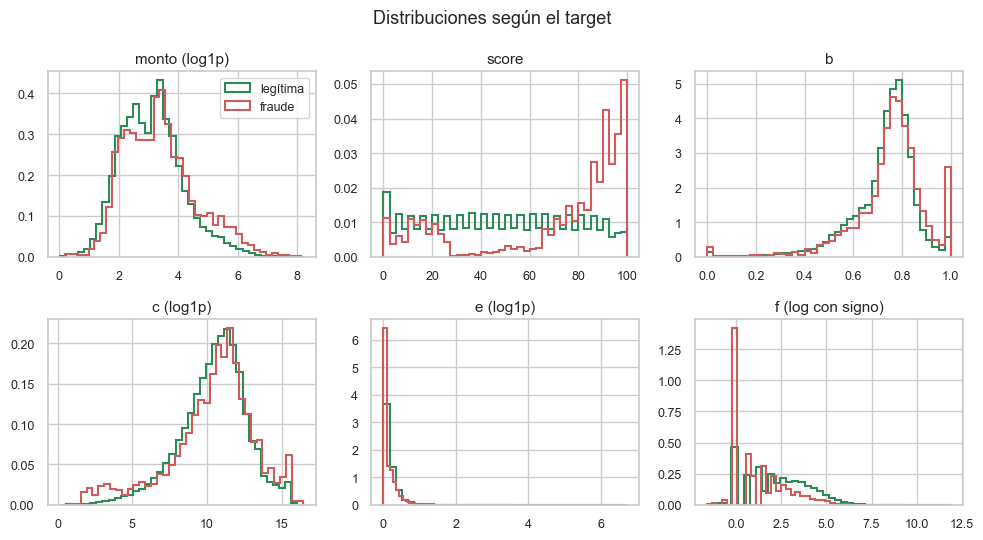

In [18]:
comparaciones = {
    "monto": "log1p",
    "score": "original",
    "b": "original",
    "c": "log1p",
    "e": "log1p",
    "f": "log con signo",
}

fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
for ax, (col, escala) in zip(axes.ravel(), comparaciones.items()):
    for clase, etiqueta, color in [(0, "legítima", "seagreen"), (1, "fraude", "indianred")]:
        valores = df.loc[df[TARGET].eq(clase), col].dropna()
        if escala == "log1p":
            valores = np.log1p(valores)
        elif escala == "log con signo":
            valores = np.sign(valores) * np.log1p(valores.abs())
        ax.hist(valores, bins=40, density=True, histtype="step", linewidth=1.5,
                label=etiqueta, color=color)
    titulo = f"{col} ({escala})" if escala != "original" else col
    ax.set_title(titulo, fontsize=11)
    ax.tick_params(labelsize=9)
axes[0, 0].legend(fontsize=9)
fig.suptitle("Distribuciones según el target", fontsize=13)
plt.tight_layout()
plt.show()

Los gráficos permiten ver cambios de forma y desplazamientos que una correlación sola puede perder. score es la única variable donde aparece una diferencia visual clara entre las clases, especialmente en los valores altos. En monto, los fraudes muestran una cola derecha algo más pesada, pero la mayor parte de ambas distribuciones se superpone

## 6. Outliers

Para cada variable numérica calculo el rango intercuartílico (la distancia entre el percentil 25 y el 75) y marco como outlier todo valor que cae por debajo de Q1 menos 1.5 veces ese rango, o por encima de Q3 más 1.5 veces ese rango, la misma regla que usan los boxplots para dibujar los puntos sueltos. Dejo afuera a n, porque al ser binaria el rango intercuartílico es cero y la regla terminaría marcando como outlier a toda la clase minoritaria.

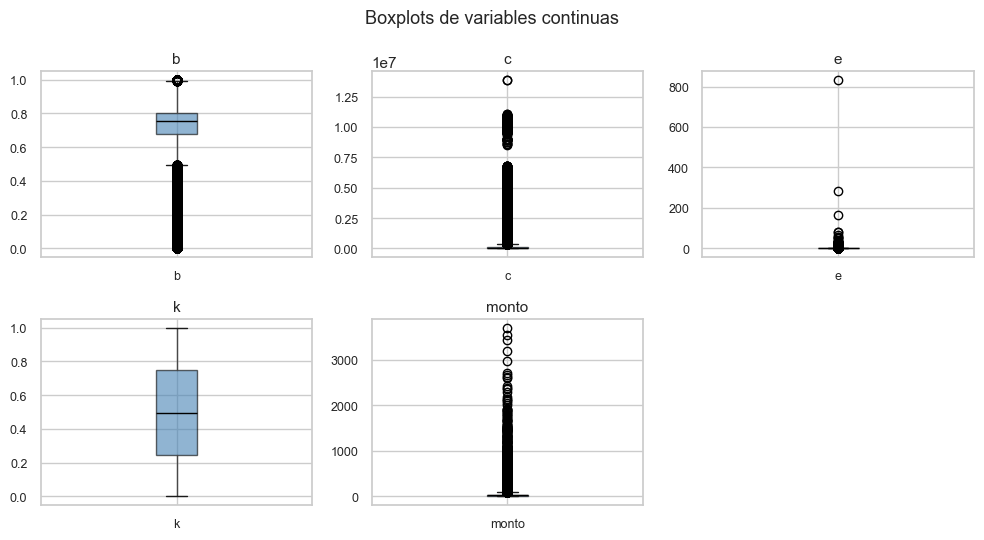

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
for ax, c in zip(axes.ravel(), COL_CONTINUAS):
    df.boxplot(column=c, ax=ax, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               medianprops=dict(color="black"))
    ax.set_title(c, fontsize=11)
    ax.tick_params(labelsize=9)
for ax in axes.ravel()[len(COL_CONTINUAS):]:
    ax.axis("off")
fig.suptitle("Boxplots de variables continuas", fontsize=13)
plt.tight_layout()
plt.show()

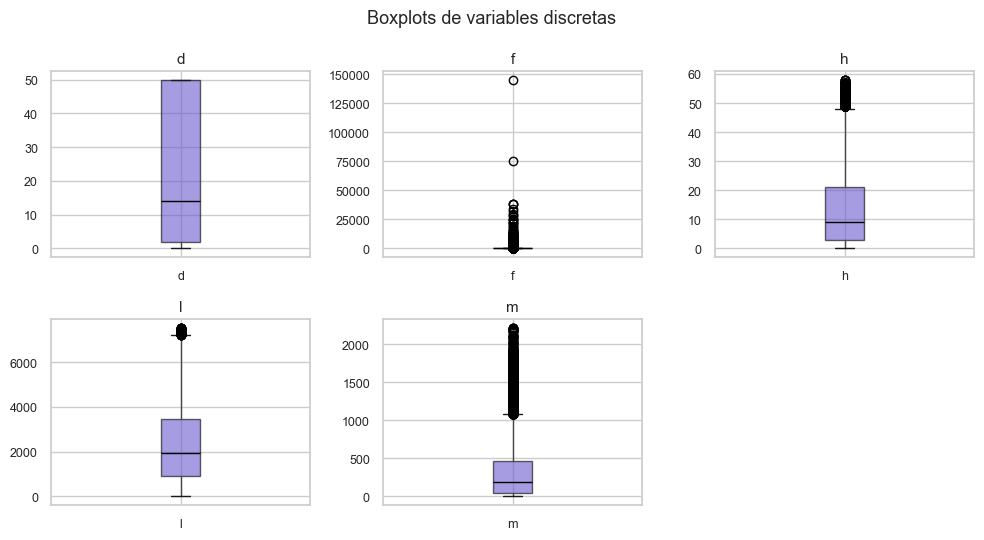

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
for ax, c in zip(axes.ravel(), COL_DISCRETAS):
    df.boxplot(column=c, ax=ax, patch_artist=True,
               boxprops=dict(facecolor="slateblue", alpha=0.6),
               medianprops=dict(color="black"))
    ax.set_title(c, fontsize=11)
    ax.tick_params(labelsize=9)
for ax in axes.ravel()[len(COL_DISCRETAS):]:
    ax.axis("off")
fig.suptitle("Boxplots de variables discretas", fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
def es_outlier_iqr(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    return (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)

cols_iqr = COL_CONTINUAS + COL_DISCRETAS + COL_SCORE
resumen_outliers = pd.DataFrame({
    c: [es_outlier_iqr(c).sum(), es_outlier_iqr(c).mean()] for c in cols_iqr
}, index=["n_outliers", "pct_outliers"]).T.sort_values("pct_outliers", ascending=False)
resumen_outliers

,n_outliers,pct_outliers
f,"14,087.0000",0.1164
c,"13,335.0000",0.1102
monto,"11,879.0000",0.0982
b,"7,180.0000",0.0593
e,"6,122.0000",0.0506
h,"3,958.0000",0.0327
m,"3,623.0000",0.0299
l,319.0000,0.0026
k,0.0000,0.0000
d,0.0000,0.0000


monto aparece entre las variables con más valores extremos según la regla del IQR. Como además define cuánto ganamos o perdemos, no alcanza con saber cuántos hay: quiero ver si esas operaciones también tienen una tasa de fraude distinta. Para eso separo las filas entre las que la regla marca como monto extremo y las que no, y comparo la tasa de fraude y el tamaño de cada grupo.

In [22]:
es_outlier_monto = es_outlier_iqr("monto")
grupo_monto = es_outlier_monto.map({
    False: "monto dentro del rango habitual",
    True: "monto extremo según IQR",
})

df.groupby(grupo_monto)[TARGET].agg(tasa_fraude="mean", n="size")

,tasa_fraude,n
monto,,
monto dentro del rango habitual,0.0477,109135
monto extremo según IQR,0.0891,11879


En el resumen, c y f son las dos columnas con mayor proporción de valores extremos. El porcentaje solo no muestra hasta dónde llegan sus colas, así que miro sus cinco valores más altos. La idea es dimensionar la diferencia entre esos máximos y el rango habitual

In [23]:
df[["c", "f"]].apply(lambda s: s.sort_values(ascending=False).head(5).values)

,c,f
0,"13,878,743.7100","145,274.0000"
1,"13,875,647.0100","75,535.0000"
2,"11,062,325.9700","38,350.0000"
3,"11,043,045.6600","38,077.0000"
4,"10,997,094.9600","37,941.0000"


Los resultados responden cosas distintas:

- En monto, el grupo marcado por la regla tiene una tasa de fraude de 8,9%, contra 4,8% en el resto. Los montos altos no son solamente una cola de la distribución: también tienen más fraude y mayor importancia económica.
- c y f son las columnas con mayor proporción de valores extremos, alrededor del 11% en ambas. Al mirar sus máximos aparece una cola muy larga: c supera los 13 millones y f llega a 145 mil, muy lejos de sus valores habituales. Como hay miles de casos marcados y no unos pocos puntos aislados, llamarlos errores y eliminarlos sería una conclusión apresurada.
- score no tiene valores marcados por IQR. Para score resulta más informativo comparar la tasa de fraude a lo largo de sus deciles, que es lo que hacemos en la sección siguiente.

Por ahora, entonces, no elimino ni recorto valores

## 7. Relación de las features con el target

Para las variables numéricas las parto en deciles: ordeno cada variable de menor a mayor y armo 10 grupos con la misma cantidad de transacciones cada uno (el decil 1 los valores más bajos y el 10 los más altos). Después miro la tasa de fraude en cada decil, si sube o baja, la variable trae señal sobre el fraude.

In [24]:
def tasa_fraude_por_decil(col, q=10):
    """Tasa de fraude por decil: 10 grupos de igual tamaño, ordenados de menor a mayor."""
    deciles = pd.qcut(df[col], q, duplicates="drop")
    return df.groupby(deciles, observed=True)[TARGET].agg(tasa_fraude="mean", n="size")

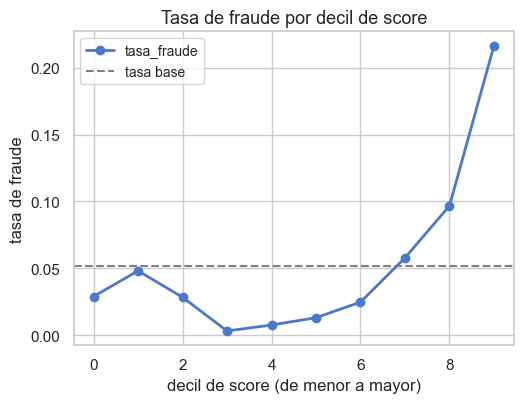

In [25]:
# Tasa de fraude a lo largo del score, agrupado en deciles.
g = tasa_fraude_por_decil("score")
fig, ax = plt.subplots(figsize=(5.4, 4.2))
g["tasa_fraude"].reset_index(drop=True).plot(marker="o", linewidth=2, ax=ax)
ax.axhline(df[TARGET].mean(), ls="--", color="gray", label="tasa base")
ax.set_xlabel("decil de score (de menor a mayor)", fontsize=12)
ax.set_ylabel("tasa de fraude", fontsize=12)
ax.set_title("Tasa de fraude por decil de score", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

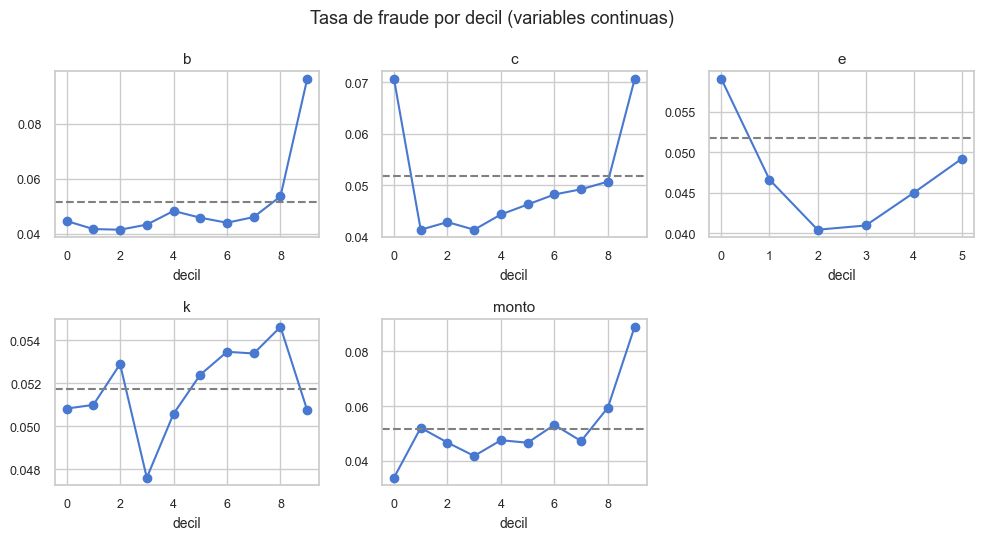

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
for ax, c in zip(axes.ravel(), COL_CONTINUAS):
    try:
        g = tasa_fraude_por_decil(c)
        g["tasa_fraude"].reset_index(drop=True).plot(marker="o", ax=ax)
        ax.axhline(df[TARGET].mean(), ls="--", color="gray")
        ax.set_title(c, fontsize=11)
        ax.set_xlabel("decil", fontsize=10)
        ax.tick_params(labelsize=9)
    except ValueError:
        ax.set_title(f"{c} (no agrupable)", fontsize=11)
        ax.axis("off")
for ax in axes.ravel()[len(COL_CONTINUAS):]:
    ax.axis("off")
fig.suptitle("Tasa de fraude por decil (variables continuas)", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
def tasa_fraude_por_nivel(col, min_n=200):
    g = df.groupby(col, dropna=False)[TARGET].agg(tasa_fraude="mean", n="size")
    return g[g["n"] >= min_n].sort_values("tasa_fraude", ascending=False)

for c in COL_CAT_BAJA + COL_BINARIAS:
    print(f"--- {c} ---")
    print(tasa_fraude_por_nivel(c))
    print()

--- a ---
   tasa_fraude       n
a                     
1       0.0919    3406
3       0.0910    2352
2       0.0791   12005
4       0.0464  103251

--- g ---
    tasa_fraude      n
g                     
BR       0.0566  91254
SE       0.0463    281
AR       0.0392  24746
US       0.0298   1714
UY       0.0113   2392

--- n ---
   tasa_fraude       n
n                     
0       0.1681   11703
1       0.0393  109311

--- p ---
   tasa_fraude      n
p                    
N       0.0791  53755
Y       0.0299  67259

--- o ---
     tasa_fraude      n
o                      
N         0.2269  13768
Y         0.0662  19592
NaN       0.0210  87654



- **score muestra una relación fuerte con fraude cuando la miramos por separado**, sobre todo en los valores altos, aunque la tasa no sube de forma ordenada en todo el rango. Esto es compatible con que sea el score de un sistema de prevención previo, pero no alcanza para afirmarlo ni para llamarlo el predictor más fuerte. 
Además, como medida de precaución, hay que confirmar que esté disponible antes de decidir si aprobamos la transacción, si se calcula después, usarlo sería leakage.
- Entre las categóricas aparecen diferencias de tasa en g, a, n, p y o. Son asociaciones descriptivas: pueden estar mezcladas con otras variables y no demuestran por sí solas capacidad predictiva fuera de muestra.
- Varias continuas muestran deciles separados de la tasa base. Eso las vuelve candidatas para investigar, pero mirarlas de a una todavía no permite medir cuánto aportan ni si su relación se mantiene junto con las demás features.

## 8. Lente económico

Paso el fraude en términos de dinero porque la función objetivo depende del monto de cada transacción y no de cuántos casos hay.

In [28]:
monto_clase = df.groupby(TARGET)["monto"].agg(["mean", "median", "sum", "count"])
monto_clase.index = ["legítima", "fraude"]
monto_clase

,mean,median,sum,count
legítima,42.1944,20.6400,"4,841,889.9000",114752
fraude,72.4515,25.7450,"453,691.0600",6262


In [29]:
monto_fraude = df.loc[df[TARGET] == 1, "monto"].sum()
monto_legit  = df.loc[df[TARGET] == 0, "monto"].sum()
monto_total  = df["monto"].sum()

# Participación del fraude en conteo vs en dinero.
share_conteo = df[TARGET].mean()
share_dinero = monto_fraude / monto_total

# Dos políticas triviales de referencia (sin modelo).
ganancia_aprobar_todo  = calcular_ganancia_aprobar_todo(df[TARGET], df["monto"])
ganancia_rechazar_todo = 0.0

print(f"Monto total:            {monto_total:,.0f}")
print(f"Monto en fraude:        {monto_fraude:,.0f}")
print(f"Fraude como % de casos: {share_conteo:.2%}")
print(f"Fraude como % de $:     {share_dinero:.2%}")
print()
print(f"Ganancia si APRUEBO TODO sobre dev: {ganancia_aprobar_todo:,.0f}")
print(f"Ganancia si RECHAZO TODO sobre dev: {ganancia_rechazar_todo:,.0f}")

Monto total:            5,295,581
Monto en fraude:        453,691
Fraude como % de casos: 5.17%
Fraude como % de $:     8.57%

Ganancia si APRUEBO TODO sobre dev: 756,781
Ganancia si RECHAZO TODO sobre dev: 0


In [30]:
# Máximo ideal: aprobar todas las legítimas y rechazar todos los fraudes
# Usa el target, así que no es una política que pudisesmos aplicar
ganancia_maxima_ideal = 0.25 * monto_legit
margen_sobre_aprobar_todo = ganancia_maxima_ideal - ganancia_aprobar_todo

print(f"Ganancia MÁXIMA IDEAL sobre todo dev:            {ganancia_maxima_ideal:,.0f}")
print(f"Margen sobre APROBAR TODO sobre dev:        {margen_sobre_aprobar_todo:,.0f}")

Ganancia MÁXIMA IDEAL sobre todo dev:            1,210,472
Margen sobre APROBAR TODO sobre dev:        453,691


### 8.1. Qué probabilidad de fraude podemos aceptar

Ya vimos que aprobar todo deja ganancia, pero también que los fraudes cuestan cuatro veces lo que ganamos con una operación legítima del mismo monto. La pregunta es: **hasta qué probabilidad de fraude nos sigue conviniendo aprobar?**

Para responderla, se hace el siguiente análisis: supongamos que un modelo estima una probabilidad de fraude $p$ para una operación de monto $M$. Si la aprobamos pueden pasar dos cosas:

- Con probabilidad $1-p$ la operación es legítima y ganamos el 25% del monto: $0{,}25M$.
- Con probabilidad $p$ es fraude y perdemos el monto completo: $M$.

Entonces, la ganancia que esperamos al aprobar es:

$$
\mathbb{E}[G_{\text{aprobar}}]
= (1-p)\,0{,}25M - pM
$$

Sacando M como factor común:

$$
\mathbb{E}[G_{\text{aprobar}}]
= M\left[0{,}25(1-p)-p\right]
$$

Nos conviene aprobar cuando esa ganancia es mayor que cero:

$$
\begin{aligned}
0{,}25(1-p)-p &> 0 \\
0{,}25-1{,}25p &> 0 \\
p &< \frac{0{,}25}{1{,}25} \\
\therefore\quad &\boxed{p < 0{,}20}
\end{aligned}
$$

La cuenta nos da un punto de corte de **20%**. Si las probabilidades del modelo representan bien el riesgo real y estos son todos los costos del problema, nos convendría aprobar operaciones con menos de 20% de probabilidad de fraude y rechazar el resto.

También aparece un resultado interesante: el monto cambia cuánto ganamos o perdemos, pero no cambia este punto de corte porque multiplica a toda la cuenta

Además de las dos políticas simples, podemos describir qué pasaría si usáramos score como una regla directa: aprobar por debajo de un corte (el mejor) y rechazar desde ese valor. Esto no es entrenamiento ni una elección final del umbral, usa todo el dev set y por eso el resultado puede verse mejor de lo que funcionaría con datos nuevos. Sirve para tener una referencia de lo que ya ofrece la variable que parece representar al sistema actual.

In [31]:
politicas_score = []
for corte in range(df["score"].min(), df["score"].max() + 2):
    aprobar = df["score"] < corte
    ganancia = ganancia_total(df[TARGET], df["monto"], aprobar)
    politicas_score.append({
        "corte": corte,
        "ganancia": ganancia,
        "tasa_aprobacion": aprobar.mean(),
    })

politicas_score = pd.DataFrame(politicas_score)
mejor_corte_descriptivo = politicas_score.loc[politicas_score["ganancia"].idxmax()]
mejor_corte_descriptivo

corte                  91.0000
ganancia          798,966.2775
tasa_aprobacion         0.9173
Name: 91, dtype: float64

En esta muestra, la mejor regla de este tipo rechaza score mayor o igual a 91 y deja una ganancia de 798.966 en dev, aprobando alrededor del 91,7% de las operaciones. Es una referencia más exigente que aprobar todo, pero no una estimación de desempeño: el corte se eligió mirando los mismos datos sobre los que se calcula la ganancia. Su estabilidad temporal y su comparación honesta con un modelo quedan para la etapa de validación.

### 8.2. Fraude y ganancia por segmentos

Dos grupos con la misma tasa pueden tener un impacto distinto si manejan montos diferentes. Para score miro, dentro de cada decil, la tasa de fraude, el monto medio y cuánto habría dejado aprobar todas las operaciones de ese grupo.

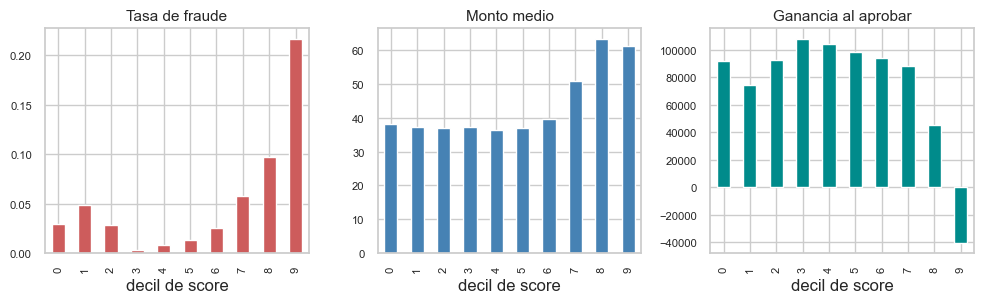

In [32]:
df_economico = df.assign(
    decil_score=pd.qcut(df["score"], 10, duplicates="drop"),
    ganancia_si_aprueba=ganancia_por_operacion(df[TARGET], df["monto"]),
)

economia_score = (
    df_economico.groupby("decil_score", observed=True)
    .agg(
        n=(TARGET, "size"),
        tasa_fraude=(TARGET, "mean"),
        monto_medio=("monto", "mean"),
        ganancia_si_aprueba=("ganancia_si_aprueba", "sum"),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
economia_score["tasa_fraude"].reset_index(drop=True).plot.bar(ax=axes[0], color="indianred")
economia_score["monto_medio"].reset_index(drop=True).plot.bar(ax=axes[1], color="steelblue")
economia_score["ganancia_si_aprueba"].reset_index(drop=True).plot.bar(ax=axes[2], color="darkcyan")
axes[0].set_title("Tasa de fraude", fontsize=11)
axes[1].set_title("Monto medio", fontsize=11)
axes[2].set_title("Ganancia al aprobar", fontsize=11)
for ax in axes:
    ax.set_xlabel("decil de score")
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

Ahora hago la misma pregunta para las categóricas y binarias: **hay algún nivel cuya aprobación completa habría producido pérdidas?** Para cada nivel calculo cantidad de operaciones, tasa de fraude, monto medio y ganancia. Solo considero niveles con al menos 200 filas para no apoyar la conclusión en grupos muy chicos.

In [33]:
# Resumen económico de niveles con al menos 200 operaciones.
resumen_segmentos = []
for col in COL_CAT_BAJA + COL_BINARIAS:
    temp = df.assign(
        nivel=df[col].fillna("faltante").astype(str),
        ganancia_si_aprueba=ganancia_por_operacion(df[TARGET], df["monto"]),
    )
    g = temp.groupby("nivel").agg(
        n=(TARGET, "size"),
        tasa_fraude=(TARGET, "mean"),
        monto_medio=("monto", "mean"),
        ganancia_si_aprueba=("ganancia_si_aprueba", "sum"),
    )
    g = g[g["n"] >= 200].reset_index()
    g.insert(0, "feature", col)
    resumen_segmentos.append(g)

resumen_segmentos = pd.concat(resumen_segmentos, ignore_index=True)
segmentos_no_rentables = (
    resumen_segmentos.query("ganancia_si_aprueba < 0")
    .sort_values("ganancia_si_aprueba")
)
segmentos_no_rentables

,feature,nivel,n,tasa_fraude,monto_medio,ganancia_si_aprueba
13,o,N,13768,0.2269,52.1109,"-116,957.9850"
9,n,0,11703,0.1681,44.9892,"-46,633.6975"


El último decil de score combina la tasa de fraude y el monto medio más altos. En esta muestra, aprobar todo ese grupo habría dejado una pérdida cercana a 40.000, mientras que los demás deciles siguen dejando ganancia.

Entre las variables categóricas aparecen dos niveles con pérdida: o = N y n = 0. Esto no significa que debamos rechazarlos automáticamente: usamos el target de la misma muestra y cada nivel todavía contiene operaciones legítimas. El resultado solo muestra que son segmentos donde una regla de aprobar todo funciona mal y donde un modelo podría encontrar señal útil.

### 8.3. Dos cruces para investigar

En vez de cruzar todas las columnas con todas, elijo dos preguntas que aparecen en el análisis: si el efecto de score cambia con el monto y si cambia según la información disponible en o. Armo grupos amplios para que cada celda tenga suficientes observaciones.

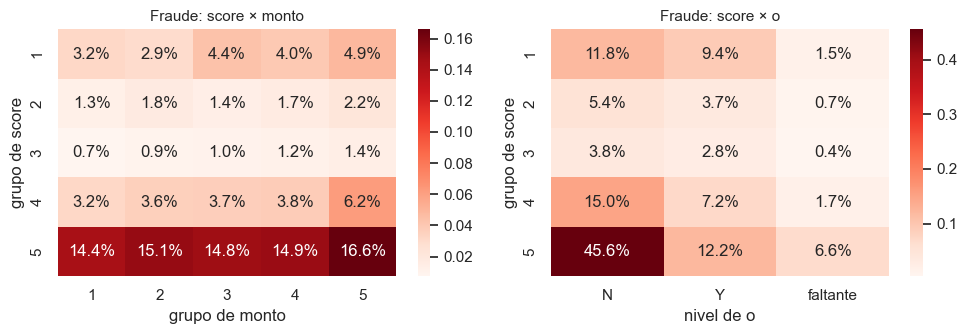

In [34]:
cruces = df.assign(
    grupo_score=pd.qcut(df["score"], 5, labels=[1, 2, 3, 4, 5], duplicates="drop"),
    grupo_monto=pd.qcut(df["monto"], 5, labels=[1, 2, 3, 4, 5], duplicates="drop"),
    nivel_o=df["o"].fillna("faltante"),
)

fraude_score_monto = cruces.pivot_table(
    index="grupo_score", columns="grupo_monto", values=TARGET, aggfunc="mean", observed=True
)
fraude_score_o = cruces.pivot_table(
    index="grupo_score", columns="nivel_o", values=TARGET, aggfunc="mean", observed=True
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.heatmap(fraude_score_monto, annot=True, fmt=".1%", cmap="Reds", ax=axes[0])
sns.heatmap(fraude_score_o, annot=True, fmt=".1%", cmap="Reds", ax=axes[1])
axes[0].set_title("Fraude: score × monto", fontsize=11)
axes[1].set_title("Fraude: score × o", fontsize=11)
axes[0].set_xlabel("grupo de monto")
axes[1].set_xlabel("nivel de o")
for ax in axes:
    ax.set_ylabel("grupo de score")
plt.tight_layout()
plt.show()

El cruce con monto muestra que, dentro de casi todos los grupos de score, la tasa de fraude tiende a ser algo mayor en los montos altos. El cruce con o es más marcado: para un mismo grupo de score, o = N tiene más fraude que o = Y, y ambos superan a las filas donde o falta. Esto refuerza la idea de que score, monto y o no cuentan exactamente la misma parte del problema

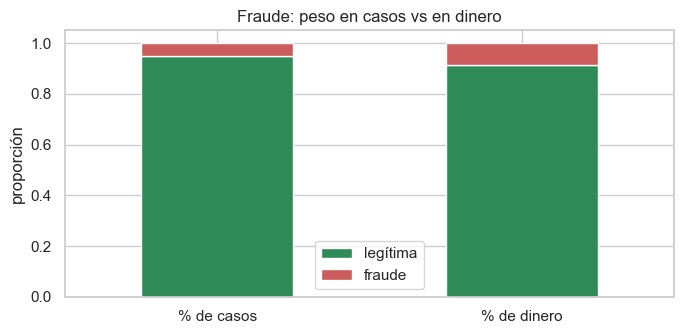

,% de casos,% de dinero
legítima,0.9483,0.9143
fraude,0.0517,0.0857


In [35]:
comp = pd.DataFrame({
    "% de casos":  [1 - share_conteo, share_conteo],
    "% de dinero": [1 - share_dinero, share_dinero],
}, index=["legítima", "fraude"])
ax = comp.T.plot.bar(rot=0, stacked=True, color=["seagreen", "indianred"])
ax.set_ylabel("proporción")
ax.set_title("Fraude: peso en casos vs en dinero")
plt.tight_layout()
plt.show()
comp

## 9. Análisis temporal

In [36]:
# Parseamos fecha solo para explorar (no modificamos el dataset de modelado).
fecha = pd.to_datetime(df["fecha"])
print(f"Rango: {fecha.min()}  ->  {fecha.max()}")
print(f"Días cubiertos: {fecha.dt.normalize().nunique()}")

Rango: 2020-03-08 00:02:15  ->  2020-04-14 23:59:39
Días cubiertos: 38


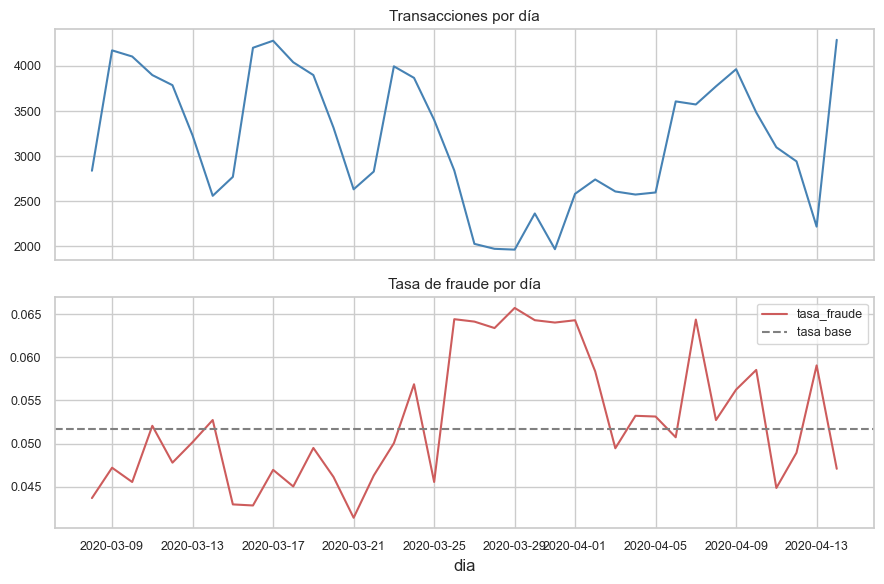

In [37]:
diario = (
    df.assign(dia=fecha.dt.date)
      .groupby("dia")[TARGET]
      .agg(n="size", tasa_fraude="mean")
)
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
diario["n"].plot(ax=axes[0], color="steelblue")
axes[0].set_title("Transacciones por día", fontsize=11)
axes[0].tick_params(labelsize=9)
diario["tasa_fraude"].plot(ax=axes[1], color="indianred")
axes[1].axhline(df[TARGET].mean(), ls="--", color="gray", label="tasa base")
axes[1].set_title("Tasa de fraude por día", fontsize=11)
axes[1].tick_params(labelsize=9)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### 9.1. Estabilidad de las features

Que la tasa de fraude cambie es solo una parte. También puede cambiar el tipo de operaciones que llegan. Miro por semana algunas variables importantes y dos proporciones categóricas.

Para que los gráficos sean más fáciles de leer, uso Semana calendario 1 a Semana calendario 7 en lugar de mostrar el rango completo:

- Semana calendario 1: 8 de marzo.
- Semana calendario 2: 9 al 15 de marzo.
- Semana calendario 3: 16 al 22 de marzo.
- Semana calendario 4: 23 al 29 de marzo.
- Semana calendario 5: 30 de marzo al 5 de abril.
- Semana calendario 6: 6 al 12 de abril.
- Semana calendario 7: 13 y 14 de abril.

Estas son semanas calendario de lunes a domingo y no corresponden a los futuros folds de validación, que usarán otros límites. El conjunto de dev set empieza el domingo 8 de marzo y termina el martes 14 de abril (la semana del 15 al 21 de abril queda reservada como test), por eso la Semana calendario 1 y la 7 tienen menos días y menos operaciones que las demás, y sus movimientos se interpretan con más cuidado.

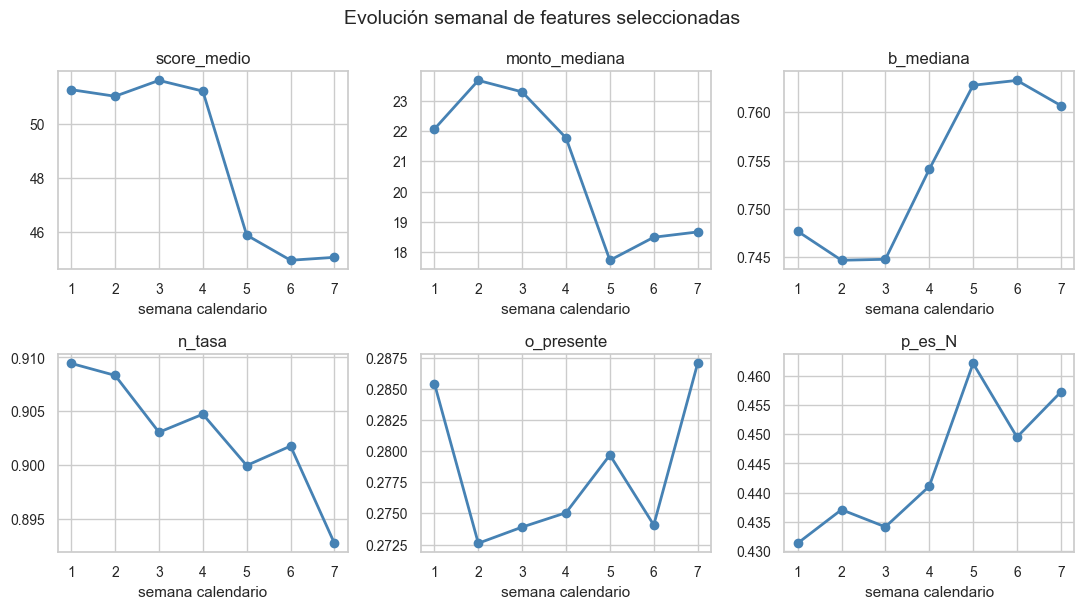

In [38]:
periodo_semana = fecha.dt.to_period("W")
mapa_semana = {
    periodo: f"Semana calendario {i}"
    for i, periodo in enumerate(sorted(periodo_semana.unique()), start=1)
}
semana = periodo_semana.map(mapa_semana)

estabilidad = (
    df.assign(
        semana=semana,
        o_presente=df["o"].notna(),
        p_es_N=df["p"].eq("N"),
    )
    .groupby("semana")
    .agg(
        score_medio=("score", "mean"),
        monto_mediana=("monto", "median"),
        b_mediana=("b", "median"),
        n_tasa=("n", "mean"),
        o_presente=("o_presente", "mean"),
        p_es_N=("p_es_N", "mean"),
    )
)

fig, axes = plt.subplots(2, 3, figsize=(11, 6.2))
for ax, col in zip(axes.ravel(), estabilidad.columns):
    estabilidad[col].plot(ax=ax, marker="o", linewidth=2, color="steelblue")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("semana calendario", fontsize=11)
    ax.set_xticks(range(len(estabilidad.index)))
    ax.set_xticklabels(range(1, len(estabilidad.index) + 1))
    ax.tick_params(axis="x", labelrotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
fig.suptitle("Evolución semanal de features seleccionadas", fontsize=14)
plt.tight_layout()
plt.show()

Mirando solamente las semanas completas, score se mantiene cerca de 51 durante las primeras semanas y baja a valores cerca de 45 desde la Semana calendario 5. La mediana de monto también baja.

El cambio no aparece igual en todas las variables. b, n y la proporción de filas donde o está presente se mantienen más estables, p = N aumenta levemente. 

Esto muestra que la composición de las operaciones cambia durante el período, especialmente en score y monto, y refuerza la decisión de validar respetando el tiempo en lugar de mezclar fechas al azar.

Con solo 38 días de dev set no alcanza para explicar la causa ni saber si el cambio continuará

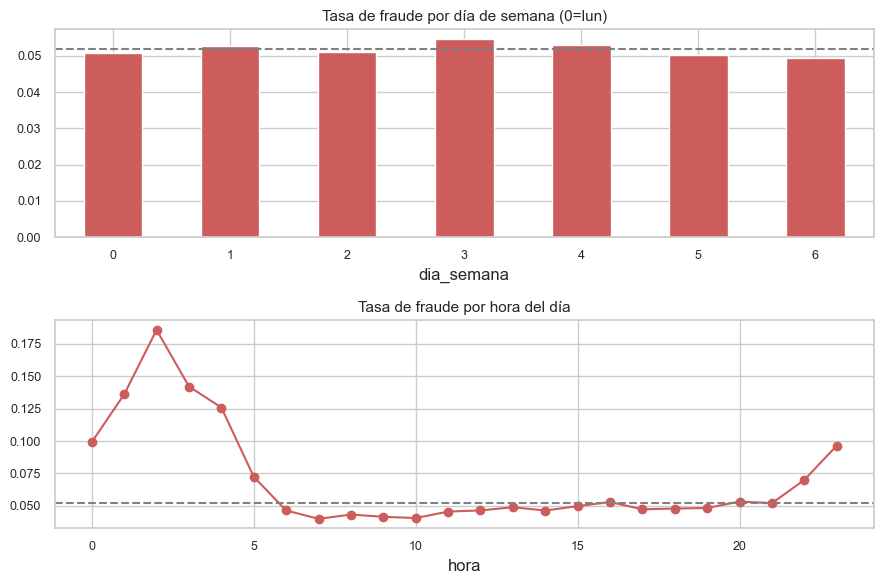

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
df.assign(dia_semana=fecha.dt.dayofweek).groupby("dia_semana")[TARGET].mean().plot.bar(rot=0, ax=axes[0], color="indianred")
axes[0].axhline(df[TARGET].mean(), ls="--", color="gray")
axes[0].set_title("Tasa de fraude por día de semana (0=lun)", fontsize=11)
axes[0].tick_params(labelsize=9)
df.assign(hora=fecha.dt.hour).groupby("hora")[TARGET].mean().plot(ax=axes[1], marker="o", color="indianred")
axes[1].axhline(df[TARGET].mean(), ls="--", color="gray")
axes[1].set_title("Tasa de fraude por hora del día", fontsize=11)
axes[1].tick_params(labelsize=9)
plt.tight_layout()
plt.show()

El dev cubre 38 días y no muestra un patrón estable por día u hora. La variación observada refuerza el uso de un split temporal, pero no alcanza para afirmar estacionalidad o drift sostenido.

### 9.2. Repetición y aparición de categorías en j

Como j tiene miles de categorías, aparece otra pregunta: son valores que se repiten o categorías que aparecen una vez y desaparecen?

Primero cuento en cuántos días aparece cada categoría y qué parte de las operaciones pertenece a categorías que se observan en más de un día.

In [40]:
resumen_j_temporal = (
    df.assign(dia=fecha.dt.normalize())
      .groupby("j")
      .agg(
          n=(TARGET, "size"),
          dias_activos=("dia", "nunique"),
          primera_fecha=("dia", "min"),
          ultima_fecha=("dia", "max"),
          fraudes=(TARGET, "sum"),
      )
)

j_recurrentes = resumen_j_temporal["dias_activos"].gt(1)
resumen_recurrencia = pd.Series({
    "categorias_totales": len(resumen_j_temporal),
    "categorias_en_mas_de_un_dia": j_recurrentes.sum(),
    "pct_categorias_recurrentes (más de 1 día)": j_recurrentes.mean(),
    "pct_operaciones_en_categorias_recurrentes": df["j"].isin(
        resumen_j_temporal.index[j_recurrentes]
    ).mean(),
    "mediana_dias_activos": resumen_j_temporal["dias_activos"].median(),
})
resumen_recurrencia

categorias_totales                          7,898.0000
categorias_en_mas_de_un_dia                 5,551.0000
pct_categorias_recurrentes (más de 1 día)       0.7028
pct_operaciones_en_categorias_recurrentes       0.9803
mediana_dias_activos                            3.0000
dtype: float64

También quiero saber si los fraudes están repartidos entre muchas categorías o concentrados en pocas. Para evitar elegir categorías mirando solo su tasa las ordeno por cantidad total de fraudes y calculo qué porcentaje acumulan los grupos superiores. Esto puede estar influido por el volumen de operaciones de cada categoría, así que no lo interpreto como riesgo individual.

In [41]:
concentracion_j = []
for pct in [0.01, 0.05, 0.10]:
    n_categorias = int(np.ceil(len(resumen_j_temporal) * pct))
    fraudes_grupo = resumen_j_temporal.nlargest(n_categorias, "fraudes")["fraudes"].sum()
    concentracion_j.append({
        "grupo_superior": f"{pct:.0%} de categorías",
        "n_categorias": n_categorias,
        "pct_de_fraudes": fraudes_grupo / resumen_j_temporal["fraudes"].sum(),
    })

pd.DataFrame(concentracion_j)

,grupo_superior,n_categorias,pct_de_fraudes
0,1% de categorías,79,0.4146
1,5% de categorías,395,0.7073
2,10% de categorías,790,0.8456


Por último, miro la llegada de categorías nuevas. Comparo los últimos siete días de dev set con todo lo observado antes: una categoría es nueva si aparece al final pero no existía en la parte anterior del período

In [42]:
corte_ultima_semana = fecha.max() - pd.Timedelta(days=7)
j_vistas_antes = set(df.loc[fecha <= corte_ultima_semana, "j"])
ultimos_7_dias = df.loc[fecha > corte_ultima_semana]
j_ultimos_7_dias = pd.Index(ultimos_7_dias["j"].unique())

resumen_j_nuevas = pd.Series({
    "operaciones_ultimos_7_dias": len(ultimos_7_dias),
    "categorias_ultimos_7_dias": len(j_ultimos_7_dias),
    "pct_categorias_nuevas": (~j_ultimos_7_dias.isin(j_vistas_antes)).mean(),
    "pct_operaciones_con_categoria_nueva": (~ultimos_7_dias["j"].isin(j_vistas_antes)).mean(),
})
resumen_j_nuevas

operaciones_ultimos_7_dias            23,771.0000
categorias_ultimos_7_dias              4,161.0000
pct_categorias_nuevas                      0.1154
pct_operaciones_con_categoria_nueva        0.0225
dtype: float64

El resultado muestra bastante repetición: cerca del 70% de las categorías aparece en más de un día y esas categorías son alrededor del 98% de las operaciones. A la vez, el 1% de categorías con más fraudes concentra cerca del 41% de los casos, aunque parte de esa concentración puede explicarse por su mayor volumen.

En los últimos siete días de dev set (8 al 14 de abril), alrededor del 11,5% de las categorías observadas son nuevas, pero representan cerca del 2,2% de las operaciones. j puede ser útil porque muchas categorías reaparecen, pero cualquier evaluación futura también debería comprobar qué pasa con las categorías no vistas y evitar depender solamente de memorizar las conocidas.

## 10. Correlaciones

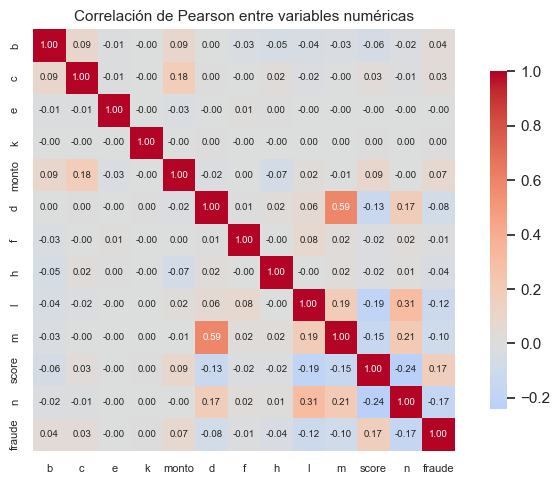

In [43]:
corr = df[COL_NUMERICAS + [TARGET]].corr()
plt.figure(figsize=(7.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Correlación de Pearson entre variables numéricas", fontsize=11)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [44]:
corr_spearman = df[COL_NUMERICAS + [TARGET]].corr(method="spearman")
comparacion = pd.DataFrame({
    "pearson": corr[TARGET].drop(TARGET),
    "spearman": corr_spearman[TARGET].drop(TARGET),
})
comparacion.sort_values("spearman", key=abs, ascending=False)

,pearson,spearman
score,0.1718,0.1725
n,-0.1718,-0.1718
f,-0.0122,-0.1409
l,-0.1175,-0.1331
m,-0.0958,-0.1232
d,-0.0798,-0.0900
b,0.0399,0.0472
monto,0.0731,0.0470
h,-0.0355,-0.0459
e,-0.0017,-0.0259


Pearson mide relaciones lineales y Spearman relaciones monotónicas por rango. La mayor diferencia aparece en f, donde Spearman detecta una asociación que los valores extremos ocultan en Pearson; en c ocurre lo contrario. score mantiene resultados similares y k queda cerca de cero. Ninguna de estas métricas mide el aporte multivariado de una feature.

## 11. Conclusiones e ideas para modelado

**Datos.** El desarrollo contiene 121.014 transacciones y 5,2% de fraude. Los faltantes más relevantes son o, cuya ausencia aporta señal, y el bloque compartido de b y c.

**Features.** score, o y monto muestran las asociaciones más claras. Se evaluarán escenarios con y sin score por su disponibilidad incierta. k queda pendiente de validación y j requiere un tratamiento que soporte alta cardinalidad y categorías nuevas. Los modelos lineales necesitarán transformaciones e imputación; los árboles pueden trabajar con las variables más directamente.

**Negocio.** Aprobar todo deja 756.781 en desarrollo y la mejor regla retrospectiva de score, 798.966. Si las probabilidades están calibradas, el umbral económico es 0,20.

**Validación.** Los cambios temporales observados justifican entrenar con el pasado y validar sobre períodos futuros. Los próximos notebooks definirán los folds, compararán modelos y revisarán calibración.